# Store Sales Forecasting — Day 2: Data Cleaning + Preprocessing
**Goal:** Build one clean master dataframe ready for feature engineering tomorrow.

**What this notebook does:**
1. Reload all 7 files (clean slate)
2. Fix oil.csv — 43 missing values via forward-fill
3. Process holidays — create `is_national_holiday`, `is_local_holiday`, `is_transferred`
4. Merge stores, oil, holidays onto train and test
5. Extract all datetime features
6. Handle zero-sales days (structural zeros, NOT missing data)
7. Save `train_clean.csv` and `test_clean.csv` for Day 3

**Output:** `../data/train_clean.csv` | `../data/test_clean.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Success: Libraries Imported")

Success: Libraries Imported


In [2]:
train = pd.read_csv('../data/train.csv', parse_dates = ['date'])
test = pd.read_csv('../data/test.csv', parse_dates = ['date'])
stores = pd.read_csv('../data/stores.csv')
oil = pd.read_csv('../data/oil.csv', parse_dates = ['date'])
holidays = pd.read_csv('../data/holidays_events.csv', parse_dates = ['date'])
transactions = pd.read_csv('../data/transactions.csv', parse_dates = ['date'])
submission = pd.read_csv('../data/sample_submission.csv')

print(f"train: {train.shape}")
print(f"test: {test.shape}")
print(f"Oil: {oil.shape} -> NULLS: {oil['dcoilwtico'].isna().sum()}")
print(f"Holidays: {holidays.shape}")

print("Success: Data Imported")

train: (3000888, 6)
test: (28512, 5)
Oil: (1218, 2) -> NULLS: 43
Holidays: (350, 6)
Success: Data Imported


## Step 1: Fix Oil Prices — Forward Fill

**Why forward-fill, not interpolation?**
Oil markets are closed on weekends and public holidays — the price is not "unknown", 
it's genuinely unchanged from the last trading day. 
Forward-fill respects this: the last known price carries forward.
Interpolation would INVENT prices between two real values — that's future data leakage.

In [4]:
# Complete Date Range so as weekends are included in the analysis
full_date_range = pd.DataFrame({
    'date' : pd.date_range(start = oil['date'].min(), end = oil['date'].max(), freq = 'D')
})

oil = full_date_range.merge(oil, on = 'date', how = 'left')
oil['dcoilwtico'] = oil['dcoilwtico'].ffill()

oil['dcoilwtico'] = oil['dcoilwtico'].bfill()

print(f"Oil: {oil.shape} -> NULLS: {oil['dcoilwtico'].isna().sum()}")
print(f"Oil Date Range: {oil['date'].min()} to {oil['date'].max()}")

print("Success: Oil Data Preprocessed")

Oil: (1704, 2) -> NULLS: 0
Oil Date Range: 2013-01-01 00:00:00 to 2017-08-31 00:00:00
Success: Oil Data Preprocessed


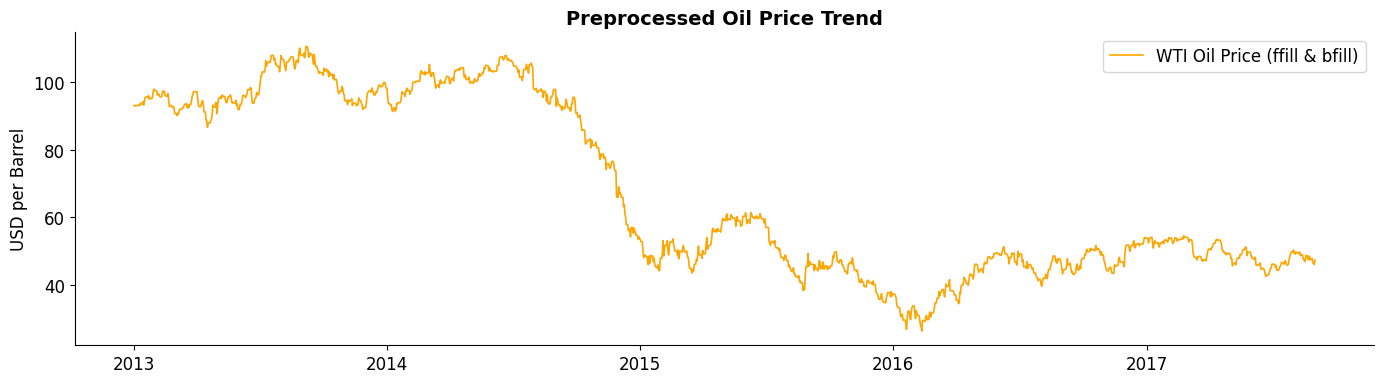

In [5]:
# Verify the preprocessed oil data through graph
fig, ax = plt.subplots(figsize = (14, 4))

ax.plot(oil['date'], oil['dcoilwtico'], color = 'orange', linewidth = 1.2, label = "WTI Oil Price (ffill & bfill)")
ax.set_title("Preprocessed Oil Price Trend", fontsize = 14, fontweight = 'bold')
ax.set_ylabel("USD per Barrel")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/oil_ffill_check.png", dpi = 150, bbox_inches = 'tight')
plt.show()

## Step 2: Process Holidays

**The `transferred` trap explained:**
- `type=Holiday` + `transferred=True` → This date is **a normal workday**. The holiday was moved.
- `type=Transfer` → This is the **actual holiday date** the celebration was moved TO.
- `type=Bridge` → A workday between two holidays made into a holiday.
- `type=Work Day` → A normally-off day that was made a workday to compensate.

**Strategy:** We create 4 binary flag columns and merge them onto train/test by date.
For local holidays, we also need the city/state to only flag relevant stores.

In [6]:
# Seperate National holidays from local holidays
national_hol = holidays[
    (holidays['locale'] == 'National') &
    (holidays['transferred'] == False) &
    (holidays['type'].isin(['Holiday', 'Transfer', 'Bridge']))
].copy()

workdays = holidays[holidays['type'] == 'Work Day']['date'].tolist()

nat_flags = national_hol[['date']].drop_duplicates().copy()
nat_flags['is_national_holiday'] = 1

local_hol = holidays[
    (holidays['locale'].isin(['Local', 'Regional'])) &
    (holidays['transferred'] == False) &
    (holidays['type'].isin(['Holiday', 'Transfer', 'Bridge']))
].copy()

local_flags = local_hol[['date', 'locale_name']].drop_duplicates().copy()
local_flags['is_local_holiday'] = 1

# Transferred holiday flag (these are NORMAL workdays — flag = 0 handled by absence)
transferred_flags = holidays[(holidays['transferred'] == True)][['date']].drop_duplicates().copy()
transferred_flags['is_transferred_holiday'] = 1     # Means original holiday date is now a workday

event_flags = holidays[holidays['type'] == 'Event'][['date']].drop_duplicates().copy()
event_flags['is_special_event'] = 1

print(f"National holiday dates : {len(nat_flags)}")
print(f"Local holiday locale records : {len(local_flags)}")
print(f"Transferred holiday dates : {len(transferred_flags)}")
print(f"Special event dates : {len(event_flags)}")

National holiday dates : 65
Local holiday locale records : 161
Transferred holiday dates : 12
Special event dates : 55


In [7]:
print("Merge above data with train and test datasets to create holiday flags for modeling")

def build_master(df, stores, oil, nat_flags, local_flags, event_flags, transferred_flags):
    """
    Merges all supplementary files onto train and test
    Returns enriched dataframe
    """

    df = df.merge(stores, on = 'store_nbr', how = 'left')
    df = df.merge(oil[['date', 'dcoilwtico']], on = 'date', how = 'left')
    df = df.merge(nat_flags, on = 'date', how = 'left')
    df['is_national_holiday'] = df['is_national_holiday'].fillna(0).astype(np.int8)
    df = df.merge(local_flags, left_on = ['date', 'city'], right_on = ['date', 'locale_name'], how = 'left')
    df['is_local_holiday'] = df['is_local_holiday'].fillna(0).astype(np.int8)
    df.drop(columns = ['locale_name'], inplace = True, errors = 'ignore')
    df = df.merge(transferred_flags, on = 'date', how = 'left')
    df['is_transferred_holiday'] = df['is_transferred_holiday'].fillna(0).astype(np.int8)
    df = df.merge(event_flags, on = 'date', how = 'left')
    df['is_special_event'] = df['is_special_event'].fillna(0).astype(np.int8)
    df['is_earthquake'] = ((df['date'] >= '2016-04-16') & (df['date'] <= '2016-05-06')).astype(np.int8)

    return df

train_clean = build_master(train, stores, oil, nat_flags, local_flags, event_flags, transferred_flags)
test_clean = build_master(test, stores, oil, nat_flags, local_flags, event_flags, transferred_flags)

print(f"train_clean shape: {train_clean.shape}")
print(f"test_clean shape: {test_clean.shape}")
print("New columns added:")
new_cols = [col for col in train_clean.columns if col not in train.columns]
print(new_cols)

print("Success: Master datasets created with merged features")


Merge above data with train and test datasets to create holiday flags for modeling
train_clean shape: (3000888, 16)
test_clean shape: (28512, 15)
New columns added:
['city', 'state', 'type', 'cluster', 'dcoilwtico', 'is_national_holiday', 'is_local_holiday', 'is_transferred_holiday', 'is_special_event', 'is_earthquake']
Success: Master datasets created with merged features


In [ ]:
print("Extract Datetime features")